# Energy–Time Parallel Simulation Analysis (Artefact)

This notebook is a artefact made to study the energy and time behaviour of the parallel workload generated by `parallel_simulator_energy`.

We will:
- Describe the experimental context and JSON outputs.
- Load and clean the raw measurements (remove outliers).
- Aggregate per-core results.
- Visualise distributions and scaling behaviour.
- Summarise the main findings.


## 1. Experimental context

The binary produced by $parallel_simulator_energy$ runs a synthetic parallel workload on a multi-core CPU. For each configuration (number of threads, sequential fraction, etc.), it:

- Executes the benchmark multiple times ($n_stat$).
- Measures **energy** (RAPL), **execution time**, **temperature**, and **voltage**.
- Stores all samples in a JSON file.

The goal of this notebook is to take such a JSON result file and perform a reproducible analysis of the scaling properties and variability, while cleaning obvious measurement outliers.


In [19]:
def load_data():
	data={
	"params":	{
		"date":	"2026-03-05 18:25:35",
		"arch":	"HSW",
		"sensor":	"PKG",
		"freq":	2.400000,
		"n_work":	1000000000,
		"n_stat":	50,
		"n_cores":	[1, 2, 3, 4, 5, 6, 7, 8],
		"seq_fraction":	0
	},
	"energy":	{
		"1_0.00_0.000000_1000000000":	[128.712646, 121.503723, 123.640564, 120.843018, 123.691345, 121.031128, 121.799377, 122.658936, 120.816467, 121.538147, 121.650452, 120.942261, 121.590088, 120.858093, 124.438049, 122.245056, 120.792786, 122.086853, 121.873352, 121.777161, 121.607971, 120.845886, 123.297058, 120.951782, 120.816528, 123.997131, 121.870911, 122.575317, 120.856384, 120.785889, 122.486084, 121.398132, 122.436951, 120.784607, 121.617432, 124.901489, 120.775269, 122.032898, 122.096680, 120.840332, 121.641785, 120.823608, 121.465942, 123.100891, 120.779419, 124.289490, 121.655762, 121.162476, 121.752075, 120.835754],
		"2_0.00_0.000000_1000000000":	[69.442383, 71.249268, 70.225891, 69.415466, 69.476685, 69.617432, 71.053894, 69.414001, 69.453857, 69.970703, 69.685364, 71.221252, 72.109863, 69.448486, 69.411621, 69.445496, 70.038391, 70.528809, 70.070557, 69.404236, 69.449341, 69.421631, 70.681458, 69.446960, 69.406555, 69.580994, 70.423645, 70.170349, 69.454590, 69.433167, 69.428284, 69.415771, 72.162048, 69.504089, 70.265991, 69.411011, 69.458557, 70.759766, 69.665710, 69.497925, 69.408630, 69.433105, 71.507446, 69.483704, 69.518738, 69.425049, 69.455933, 70.262207, 69.486816, 69.433838],
		"3_0.00_0.000000_1000000000":	[53.186707, 52.393005, 52.302490, 52.298645, 54.477905, 54.170715, 52.282471, 52.321655, 52.282471, 52.292114, 52.312195, 52.281311, 53.871948, 52.382690, 52.525391, 52.296265, 52.307861, 52.286682, 52.316040, 52.927551, 52.290466, 52.289734, 52.296692, 52.281128, 53.202393, 52.387207, 52.274841, 53.777100, 52.280396, 52.316772, 52.314270, 52.276489, 52.328979, 52.285706, 52.304016, 56.607971, 53.220825, 52.400146, 52.305664, 52.289612, 52.297607, 52.288818, 52.617126, 52.287048, 52.318420, 52.302307, 52.542297, 52.297119, 53.195862, 52.389099],
		"4_0.00_0.000000_1000000000":	[44.142578, 43.745239, 43.722351, 43.734619, 43.739563, 43.725220, 43.725769, 43.734863, 43.735229, 43.714172, 44.193848, 43.731873, 43.719910, 44.676147, 43.824707, 43.729004, 43.708862, 43.743591, 43.717468, 43.729919, 43.759216, 47.104370, 44.147522, 43.716858, 43.723022, 43.714844, 43.713196, 43.727661, 43.712219, 44.628540, 43.845886, 44.457397, 43.723816, 43.767151, 43.737122, 43.727539, 43.709595, 43.991760, 43.716125, 43.710327, 43.704285, 45.136841, 43.714966, 43.705383, 43.785034, 44.542419, 43.820984, 43.716248, 43.722351, 43.715271],
		"5_0.00_0.000000_1000000000":	[38.571167, 38.596558, 39.302612, 38.572388, 38.591248, 38.610718, 38.594299, 38.561035, 38.555237, 38.563477, 38.589172, 38.567993, 38.809998, 38.563049, 39.654663, 42.328613, 39.373413, 38.593994, 38.604126, 38.608887, 38.618164, 38.570129, 38.589111, 38.589661, 38.586853, 38.599365, 38.596252, 39.128113, 38.953979, 38.556213, 38.567749, 38.576599, 38.577209, 38.574463, 39.502014, 38.671143, 38.598694, 38.849426, 38.631592, 38.612915, 38.937561, 38.598206, 38.627014, 38.612183, 38.642822, 38.622681, 38.616333, 38.602722, 38.648743, 38.622986],
		"6_0.00_0.000000_1000000000":	[35.179321, 35.169434, 35.180786, 35.151794, 36.014099, 36.039978, 35.208435, 35.292603, 35.263367, 35.189575, 35.227356, 35.251099, 35.203369, 35.283142, 35.245056, 35.264160, 35.226379, 35.334839, 35.239258, 37.560669, 37.308411, 35.584045, 35.370667, 35.338074, 35.520691, 35.444214, 35.479614, 35.519287, 35.598694, 36.004639, 35.538818, 35.456482, 35.443054, 35.504883, 35.892395, 35.824585, 35.567505, 35.544800, 35.593689, 35.672974, 35.551697, 35.670105, 35.784363, 35.719788, 35.745483, 35.872803, 35.664429, 35.955261, 36.031006, 35.780823],
		"7_0.00_0.000000_1000000000":	[34.150574, 33.928467, 33.935303, 34.335144, 34.147217, 33.922546, 33.966980, 33.936707, 33.936646, 33.938538, 33.940857, 33.942200, 33.945862, 33.939331, 33.938660, 33.932007, 33.933289, 33.917542, 34.337341, 33.906921, 33.944275, 33.950134, 33.948242, 33.941284, 33.946228, 33.945190, 33.947205, 33.942749, 33.946289, 33.947937, 33.950989, 34.533081, 33.995483, 33.970947, 33.926636, 34.196655, 35.437744, 35.174927, 33.900391, 33.917603, 33.889832, 33.874084, 33.857178, 33.916199, 33.903625, 33.918274, 33.906433, 33.911743, 33.880310, 33.899902],
		"8_0.00_0.000000_1000000000":	[31.790344, 31.895874, 31.928040, 31.881592, 32.051819, 31.905396, 31.855957, 31.895325, 31.899963, 31.910645, 32.222290, 32.095642, 31.894165, 31.909363, 31.914001, 31.864380, 31.906128, 31.917969, 31.879089, 31.924744, 31.909973, 31.918030, 31.884399, 31.929382, 31.986572, 31.929016, 32.099792, 31.913147, 31.875610, 31.925293, 31.923828, 31.922424, 31.883423, 31.920471, 31.930603, 31.924866, 31.882080, 31.926941, 31.927917, 31.924927, 31.883545, 31.931335, 31.991333, 32.475586, 31.907898, 32.049561, 31.883179, 31.924316, 31.933655, 31.927307]
	},
	"time":	{
		"1_0.00_0.000000_1000000000":	[5.841249, 5.840703, 5.841066, 5.840338, 5.841655, 5.840407, 5.840636, 5.841059, 5.840330, 5.840852, 5.840626, 5.840458, 5.841257, 5.840653, 5.841269, 5.840541, 5.840203, 5.840746, 5.840394, 5.840889, 5.840443, 5.840351, 5.840956, 5.840424, 5.840270, 5.841053, 5.840519, 5.840784, 5.840410, 5.840244, 5.840853, 5.840479, 5.841191, 5.840372, 5.840410, 5.841114, 5.840255, 5.840893, 5.840275, 5.840279, 5.841170, 5.840226, 5.840427, 5.842527, 5.840473, 5.841558, 5.840426, 5.840070, 5.840796, 5.840136],
		"2_0.00_0.000000_1000000000":	[2.920870, 2.920992, 2.920831, 2.920887, 2.920717, 2.920789, 2.921484, 2.921099, 2.920780, 2.920824, 2.920938, 2.921292, 2.920892, 2.920851, 2.920765, 2.920854, 2.921389, 2.920883, 2.920851, 2.920913, 2.920852, 2.920731, 2.921589, 2.920766, 2.920820, 2.920922, 2.920760, 2.921518, 2.920945, 2.920934, 2.920774, 2.920792, 2.921373, 2.920955, 2.920911, 2.920901, 2.920805, 2.921097, 2.921044, 2.920870, 2.920762, 2.920877, 2.921488, 2.920973, 2.920913, 2.920818, 2.920814, 2.921762, 2.920763, 2.920896],
		"3_0.00_0.000000_1000000000":	[1.972809, 1.947306, 1.947484, 1.947447, 2.002324, 2.020035, 1.947137, 1.947263, 1.947141, 1.947300, 1.947104, 1.947144, 1.973200, 1.947172, 1.955079, 1.947138, 1.947289, 1.947126, 1.947326, 1.947927, 1.947073, 1.947100, 1.947297, 1.947086, 1.972747, 1.947232, 1.947219, 1.947690, 1.947127, 1.947345, 1.947093, 1.947094, 1.947450, 1.947107, 1.947235, 2.075986, 1.972901, 1.947532, 1.947109, 1.947107, 1.947186, 1.947120, 1.947508, 1.947257, 1.947096, 1.947240, 1.954906, 1.947137, 1.972675, 1.947113],
		"4_0.00_0.000000_1000000000":	[1.463115, 1.460544, 1.460352, 1.460464, 1.460456, 1.460479, 1.460420, 1.460453, 1.460414, 1.460500, 1.460731, 1.460432, 1.460501, 1.486169, 1.460486, 1.460434, 1.460403, 1.460399, 1.460452, 1.460515, 1.460349, 1.573329, 1.475481, 1.460542, 1.460496, 1.460417, 1.460414, 1.460509, 1.460411, 1.486173, 1.460383, 1.461028, 1.460396, 1.460435, 1.460398, 1.460434, 1.460468, 1.468787, 1.460509, 1.460402, 1.460410, 1.460876, 1.460448, 1.460379, 1.460497, 1.486130, 1.460420, 1.460370, 1.460365, 1.460471],
		"5_0.00_0.000000_1000000000":	[1.168522, 1.168467, 1.169262, 1.168327, 1.168439, 1.168551, 1.168368, 1.168473, 1.168349, 1.168456, 1.168453, 1.168571, 1.168530, 1.168667, 1.194315, 1.266439, 1.198474, 1.168671, 1.168350, 1.168523, 1.168480, 1.168323, 1.168471, 1.168464, 1.168353, 1.168441, 1.168428, 1.169034, 1.168572, 1.168365, 1.168482, 1.168482, 1.168349, 1.168535, 1.194178, 1.168343, 1.168484, 1.175447, 1.169318, 1.168552, 1.168805, 1.168751, 1.168491, 1.168549, 1.168464, 1.168469, 1.168342, 1.168467, 1.168520, 1.168364],
		"6_0.00_0.000000_1000000000":	[0.973766, 0.973648, 0.973534, 0.973636, 0.974428, 0.999702, 0.973571, 0.973653, 0.974030, 0.973568, 0.973644, 0.973641, 0.973574, 0.973707, 0.973784, 0.973629, 0.973548, 0.973624, 0.973646, 1.020107, 1.052116, 0.976837, 0.973739, 0.973688, 0.973652, 0.973691, 0.973670, 0.973544, 0.981581, 0.991251, 0.974000, 0.973562, 0.973634, 0.973656, 0.974622, 0.973980, 0.973712, 0.973694, 0.973638, 0.973727, 0.973725, 0.973755, 0.973751, 0.973700, 0.973629, 0.973734, 0.973749, 0.973628, 0.982017, 0.973681],
		"7_0.00_0.000000_1000000000":	[0.835382, 0.834590, 0.834565, 0.851674, 0.843257, 0.834613, 0.834748, 0.834581, 0.834583, 0.834617, 0.834577, 0.834576, 0.834609, 0.834628, 0.834662, 0.834651, 0.834716, 0.834591, 0.839255, 0.834614, 0.834629, 0.834743, 0.834614, 0.834607, 0.834609, 0.834600, 0.834601, 0.834582, 0.834635, 0.834630, 0.834701, 0.858128, 0.836839, 0.834612, 0.834595, 0.836719, 0.900131, 0.895893, 0.834630, 0.834614, 0.834604, 0.834618, 0.834592, 0.834602, 0.834585, 0.834575, 0.834587, 0.834622, 0.834620, 0.834558],
		"8_0.00_0.000000_1000000000":	[0.730624, 0.730280, 0.730424, 0.730215, 0.731149, 0.730338, 0.730365, 0.730261, 0.730648, 0.730272, 0.745808, 0.740972, 0.730382, 0.730284, 0.730305, 0.730343, 0.730305, 0.730375, 0.730241, 0.730336, 0.730262, 0.730293, 0.730260, 0.730377, 0.730779, 0.730388, 0.738771, 0.730438, 0.730263, 0.730384, 0.730314, 0.730354, 0.730244, 0.730434, 0.730301, 0.730340, 0.730260, 0.730382, 0.730265, 0.730465, 0.730291, 0.730264, 0.732782, 0.753988, 0.730393, 0.730955, 0.730420, 0.730270, 0.730393, 0.730245]
	},
	"temperature":	{
		"1_0.00_0.000000_1000000000":	[44, 43, 43, 43, 42, 42, 43, 42, 42, 42, 41, 42, 42, 42, 41, 42, 41, 41, 41, 42, 42, 41, 42, 40, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 40, 40, 40, 41, 40, 41, 41, 40, 40, 40, 39, 39, 40, 40, 40, 40],
		"2_0.00_0.000000_1000000000":	[43, 43, 44, 44, 41, 42, 44, 41, 43, 41, 40, 41, 43, 40, 43, 41, 42, 43, 42, 40, 42, 42, 40, 40, 44, 40, 42, 41, 40, 42, 40, 41, 42, 44, 44, 44, 42, 41, 44, 40, 42, 42, 43, 40, 43, 44, 42, 40, 41, 43],
		"3_0.00_0.000000_1000000000":	[40, 44, 43, 40, 42, 41, 43, 44, 44, 44, 44, 42, 40, 43, 41, 44, 44, 42, 43, 42, 41, 44, 40, 43, 42, 43, 41, 41, 44, 43, 40, 40, 42, 43, 44, 43, 42, 42, 42, 42, 41, 40, 41, 40, 43, 40, 44, 44, 42, 43],
		"4_0.00_0.000000_1000000000":	[42, 41, 43, 44, 43, 41, 44, 43, 44, 41, 41, 41, 40, 44, 43, 41, 40, 43, 40, 42, 42, 43, 40, 42, 42, 44, 42, 42, 42, 42, 40, 42, 42, 42, 40, 42, 41, 44, 42, 40, 42, 44, 44, 43, 43, 41, 40, 40, 42, 40],
		"5_0.00_0.000000_1000000000":	[43, 44, 40, 41, 40, 40, 44, 41, 40, 41, 41, 40, 43, 42, 44, 42, 43, 42, 40, 42, 40, 42, 40, 43, 43, 40, 40, 40, 43, 40, 41, 42, 42, 42, 44, 42, 44, 41, 41, 40, 40, 40, 40, 44, 40, 42, 44, 43, 40, 43],
		"6_0.00_0.000000_1000000000":	[40, 44, 42, 44, 41, 40, 44, 42, 42, 43, 41, 43, 41, 44, 40, 44, 43, 40, 43, 40, 40, 44, 40, 42, 44, 40, 42, 40, 41, 40, 42, 43, 41, 44, 41, 40, 43, 41, 41, 41, 42, 43, 42, 40, 42, 42, 41, 43, 43, 40],
		"7_0.00_0.000000_1000000000":	[44, 44, 42, 43, 40, 43, 41, 42, 41, 40, 41, 42, 44, 43, 44, 42, 42, 43, 42, 43, 41, 41, 42, 43, 42, 44, 43, 42, 41, 42, 42, 43, 44, 43, 42, 41, 44, 42, 41, 41, 40, 42, 42, 42, 42, 40, 40, 40, 40, 40],
		"8_0.00_0.000000_1000000000":	[42, 42, 43, 43, 42, 42, 41, 42, 41, 42, 42, 41, 43, 43, 41, 43, 42, 41, 44, 41, 42, 40, 44, 44, 40, 41, 43, 44, 44, 41, 41, 42, 44, 41, 43, 44, 40, 44, 40, 42, 42, 43, 44, 41, 41, 43, 44, 41, 42, 44]
	},
	"voltage":	{
		"1_0.00_0.000000_1000000000":	[7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 7.259000, 6.347000, 7.259000, 7.259000, 7.219000, 7.259000, 7.259000, 7.219000, 7.219000, 7.219000, 7.259000, 7.219000, 7.219000, 7.259000, 7.219000, 7.219000],
		"2_0.00_0.000000_1000000000":	[7.259000, 7.219000, 7.259000, 7.259000, 7.259000, 7.259000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 6.347000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000, 7.219000],
		"3_0.00_0.000000_1000000000":	[7.219000, 7.180000, 7.180000, 7.180000, 7.219000, 7.219000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 6.307000, 7.219000, 7.180000, 7.219000, 7.180000, 7.180000, 6.307000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.219000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.219000, 6.347000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000],
		"4_0.00_0.000000_1000000000":	[7.180000, 7.180000, 7.180000, 6.307000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.219000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 6.307000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000, 7.180000],
		"5_0.00_0.000000_1000000000":	[7.140000, 6.267000, 7.140000, 7.140000, 6.267000, 7.180000, 7.140000, 7.180000, 7.140000, 7.140000, 6.267000, 7.140000, 6.267000, 7.140000, 7.180000, 7.180000, 6.307000, 7.180000, 7.180000, 7.140000, 7.180000, 7.140000, 7.140000, 7.180000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.180000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 6.267000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000],
		"6_0.00_0.000000_1000000000":	[7.140000, 7.140000, 6.267000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000],
		"7_0.00_0.000000_1000000000":	[7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.140000, 7.100000, 7.140000, 7.140000, 7.140000, 7.140000, 7.100000, 6.228000, 7.140000, 7.100000, 7.100000],
		"8_0.00_0.000000_1000000000":	[7.140000, 7.100000, 7.140000, 7.140000, 7.100000, 7.100000, 7.140000, 6.228000, 7.100000, 7.140000, 6.228000, 7.140000, 7.140000, 7.100000, 7.100000, 7.140000, 7.140000, 7.140000, 7.140000, 7.100000, 7.140000, 7.100000, 7.140000, 6.228000, 7.140000, 6.188000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.140000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000, 7.100000]
	}
}
	return data

In [9]:
# 2. Imports and helper functions

import json
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


def evaluate_greenup(r, n):
    """Theoretical greenup for parameter r and n cores.

    G(n) = (1 + r) / (1 + r / n)
    """
    return (1 + r) / (1 + r / n)


def calc_rat(sp_n, sp_n_p_1, n):
    """Speedup ratio helper used in scaling analysis.

    Parameters
    ----------
    sp_n : float
        Speedup with n cores.
    sp_n_p_1 : float
        Speedup with n+1 cores.
    n : int
        Current core count.
    """
    r = (sp_n_p_1 - sp_n) / (sp_n / n - sp_n_p_1 / (n + 1))
    return r


def calc_sp(ref, core_n):
    """Compute ideal speedup assuming linear scaling."""
    return ref / core_n


def clean_outliers(x, lower_quantile=0.05, upper_quantile=0.95):
    """Remove outliers based on quantiles.

    Returns the filtered Series and a boolean mask that can be
    reused on aligned arrays (e.g. time and energy).
    """
    x = pd.Series(x)
    lower = x.quantile(lower_quantile)
    upper = x.quantile(upper_quantile)
    mask = (x >= lower) & (x <= upper)
    return x[mask], mask


def med(values):
    """Median of a list/array (wrapper around statistics.median)."""
    return statistics.median(values)


def load_clean():
    """Load a JSON result file and clean energy/time samples.

    The JSON is expected to contain the keys:
    - "energy": dict mapping experiment name -> list of samples
    - "time":   dict with the same keys as "energy"
    - "voltage": dict of voltage samples per experiment
    - "temperature": dict of temperature samples per experiment
    - "params": global simulation parameters
    """
    data = load_data()

    energy_clean = {}
    time_clean = {}
    for exp_name, val in data["energy"].items():
        energy_clean_tmp, mask = clean_outliers(val)
        energy_clean[exp_name] = energy_clean_tmp
        time_clean_tmp = np.array(data["time"][exp_name])[mask]
        time_clean[exp_name] = time_clean_tmp

    voltage = data["voltage"]
    temperature = data["temperature"]
    parameters = data["params"]
    return energy_clean, time_clean, voltage, temperature, parameters


def load_raw(filename):
    """Load raw energy samples and corresponding core counts.

    Returns
    -------
    energy : list of list[float]
        Raw energy samples per experiment.
    cores : list[int]
        Core count per experiment, parsed from the experiment name.
    """
    with open(filename, "r") as f:
        data = json.load(f)
    energy = []
    cores = []
    for exp_name, val in data["energy"].items():
        energy.append(val)
        cores.append(int(exp_name.split("_")[0]))
    return energy, cores


def load_exlude_temp(filename):
    """Load energy samples restricted to a fixed reference temperature.

    The function identifies the median temperature of the first
    experiment and only keeps energy samples whose corresponding
    temperature matches this value.
    """
    with open(filename, "r") as f:
        data = json.load(f)
    n_cores = len(data["params"]["n_cores"])
    cores = []
    energy = [[] for _ in range(n_cores)]
    fixed_temp = int(med(list(data["temperature"].values())[0]))
    for exp_name, vals in data["energy"].items():
        cur_core = int(exp_name.split("_")[0])
        for i, v in enumerate(vals):
            coresp_temp = data["temperature"][exp_name][i]
            if coresp_temp == fixed_temp:
                energy[cur_core - 1].append(v)
        cores.append(cur_core)
    return energy, cores


## 2. Loading and cleaning a result file

1. Select a JSON result file produced by the C binary.
2. Load raw energy/time samples.
3. Clean outliers (per experiment name).
4. Compute summary statistics (median, mean, variance, etc.).

In [10]:
# Example: load and clean one JSON result file

energy_clean, time_clean, voltage, temperature, params = load_clean()
params


{'date': '2026-03-04 15:17:02',
 'arch': 'HSW',
 'sensor': 'PKG',
 'freq': 2.4,
 'n_work': 100000000,
 'n_stat': 10,
 'n_cores': [1, 2, 3, 4, 5, 6, 7, 8],
 'seq_fraction': 0}

## 3. Distribution analysis

Here we inspect the distribution of energy and time for a given configuration (e.g. fixed number of cores and sequential fraction), similarly to $avec_nettoyage.ipynb$.


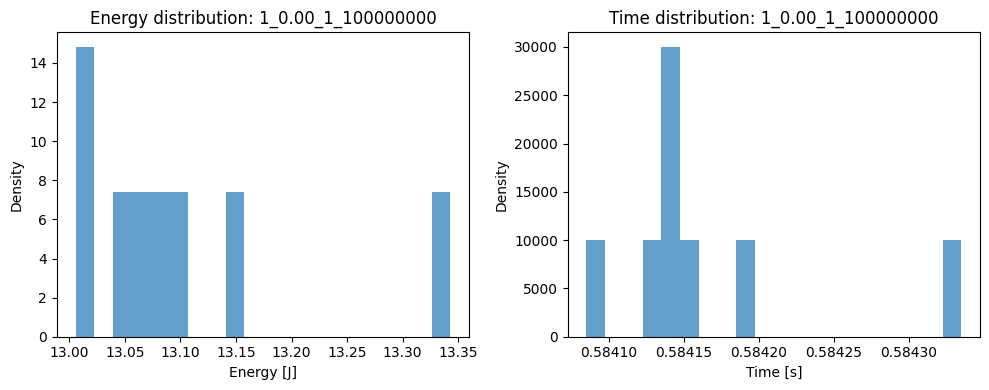

In [11]:
# Choose one experiment key, e.g. "4_0.00_1_100000000"

example_key = sorted(energy_clean.keys())[0]
e_vals = np.array(energy_clean[example_key])
t_vals = np.array(time_clean[example_key])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(e_vals, bins=20, density=True, alpha=0.7)
axes[0].set_title(f"Energy distribution: {example_key}")
axes[0].set_xlabel("Energy [J]")
axes[0].set_ylabel("Density")

axes[1].hist(t_vals, bins=20, density=True, alpha=0.7)
axes[1].set_title(f"Time distribution: {example_key}")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


## 4. Scaling of time with the number of cores

Shows how the times values are following Amdahl's model.

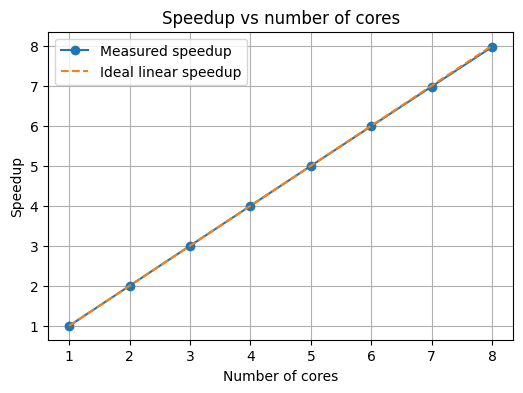

In [12]:
# Compute median energy/time and speedup per core count

core_counts = []
median_time = []
median_energy = []

for key in sorted(energy_clean.keys(), key=lambda k: int(k.split("_")[0])):
    ncores = int(key.split("_")[0])
    core_counts.append(ncores)
    median_time.append(med(time_clean[key]))
    median_energy.append(med(energy_clean[key]))

core_counts = np.array(core_counts)
median_time = np.array(median_time)
median_energy = np.array(median_energy)

# Use 1-core time as reference for speedup
t1 = median_time[core_counts == 1][0]
speedup = t1 / median_time

plt.figure(figsize=(6, 4))
plt.plot(core_counts, speedup, "o-", label="Measured speedup")
plt.plot(core_counts, core_counts, "--", label="Ideal linear speedup")
plt.xlabel("Number of cores")
plt.ylabel("Speedup")
plt.legend()
plt.title("Speedup vs number of cores")
plt.grid(True)
plt.show()


## 5. Energy scaling ("greenup")

We now study how **energy consumption** scales with the number of cores. The *greenup*, defined analogously to speedup but for energy:

- Let \(E_1\) be the median energy with 1 core.
- Let \(E_n\) be the median energy with \(n\) cores.
- The **greenup** for \(n\) cores is

$$
     G(n) = \frac{E_1}{E_n} 
$$

Values of \(G(n) > 1\) indicate that using \(n\) cores is more energy-efficient than 1 core for the same amount of work; \(G(n) < 1\) indicates an energy penalty.

### 5.1 Greenup model and asymptote

We now fit a simple *energy greenup model* based on the ratio parameter $r$ (as in the detailed notebook):

- For each adjacent pair of core counts $n$ and $n+1$, we estimate $r$ from the change in median greenup.
- We then summarise all these ratios into a single parameter (here: median $r$).
- The corresponding theoretical greenup curve is
  $ G(n) = \frac{1 + r}{1 + r / n} $
  whose horizontal asymptote as $n \to \infty$ is $1 + r$.

The figure below overlays:


- The **measured median greenup** per core.
- The **model greenup curve** $G(n)$.
- The **ideal speedup** line (linear in the number of cores).
- The **asymptotic greenup** level $1 + r$ as a horizontal dashed line.

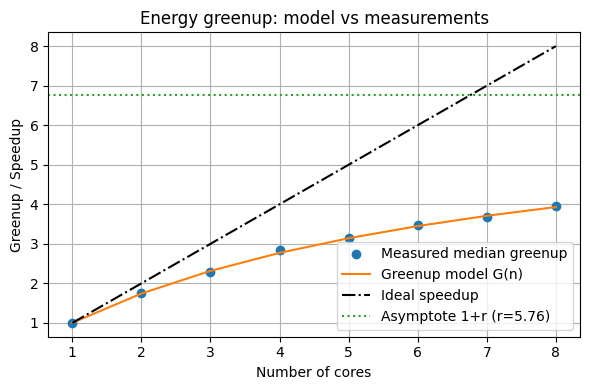

In [13]:
# Greenup model: fit r and plot model vs measurements

# Build per-core lists of greenup samples (energy-based)
core_keys = sorted(energy_clean.keys(), key=lambda k: int(k.split("_")[0]))
cores = np.array([int(k.split("_")[0]) for k in core_keys])

# Reference energy = median energy at 1 core
ref_energy = med(energy_clean[core_keys[0]])

greenup_samples = []  # list of lists per core
for key in core_keys:
    e_vals = np.array(energy_clean[key], dtype=float)
    g_vals = ref_energy / e_vals
    greenup_samples.append(list(g_vals))

# Estimate r from ratios between successive core counts
ratios = []
for i in range(len(greenup_samples) - 1):
    n = i + 1  # core count for position i
    g_n = med(greenup_samples[i])
    for g_n1 in greenup_samples[i + 1]:
        ratios.append(calc_rat(g_n, g_n1, n))

# Optionally clean extreme ratios using the same quantile-based filter
ratios_clean, _ = clean_outliers(ratios)

# Single model parameter r_hat (median of cleaned ratios)
r_hat = float(med(ratios_clean))

# Median measured greenup per core
median_greenup = np.array([med(g) for g in greenup_samples])

# Theoretical model curve and asymptote
model_greenup = np.array([evaluate_greenup(r_hat, int(n)) for n in cores])
ideal_speedup = cores.astype(float)  # reference linear speedup
asymptote = 1.0 + r_hat

plt.figure(figsize=(6, 4))
plt.plot(cores, median_greenup, "o", label="Measured median greenup", color="C0")
plt.plot(cores, model_greenup, "-", label="Greenup model G(n)", color="C1")
plt.plot(cores, ideal_speedup, "k-.", label="Ideal speedup", linewidth=1.5)
plt.axhline(y=asymptote, linestyle=":", color="C2", label=f"Asymptote 1+r (r={r_hat:.2f})")

plt.xlabel("Number of cores")
plt.ylabel("Greenup / Speedup")
plt.title("Energy greenup: model vs measurements")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Conclusion

This notebook provides artefact containing:

- Helper functions to load → clean → analyse → visualise.
- Sections introducing experimental context, data preparation, distribution analysis, and scaling behaviour.